In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch import optim
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt

from simple1Dnn import onedim_model, xy_dataset


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [44]:
#hyperparameters
N = 5000 #number of datapoints
learning_rate = 0.01
batch_size = 400 #model will compute loss and update parameters after batch_size samples have gone through it
training_epochs = 20
training_ratio = 0.8 #percentage of datapoints to use for training


In [45]:
model = onedim_model(in_channels=100, num_classes=100).to(device)
loss = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [46]:
x = np.linspace(-2*np.pi, 2*np.pi, num = N)
y = np.cos(x)

rng = np.random.default_rng(42)
permuted_idxs = rng.permutation(N)

n_train = int(training_ratio * N)

train_idxs, test_idxs = permuted_idxs[:n_train], permuted_idxs[n_train:]
train_dataset = xy_dataset(x[train_idxs], y[train_idxs], split="train" )
test_dataset = xy_dataset(x[test_idxs], y[test_idxs], split="test" )


"""train_dataset, test_dataset = random_split(dataset, [n_train, n_test],
                                   generator=torch.Generator().manual_seed(42))"""

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

Epoch [1/20]


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 63.36it/s]


Epoch [2/20]


100%|██████████| 10/10 [00:00<00:00, 105.14it/s]


...

100%|██████████| 10/10 [00:00<00:00, 103.03it/s]


Epoch [19/20]


100%|██████████| 10/10 [00:00<00:00, 93.78it/s]


Epoch [20/20]


100%|██████████| 10/10 [00:00<00:00, 91.93it/s]


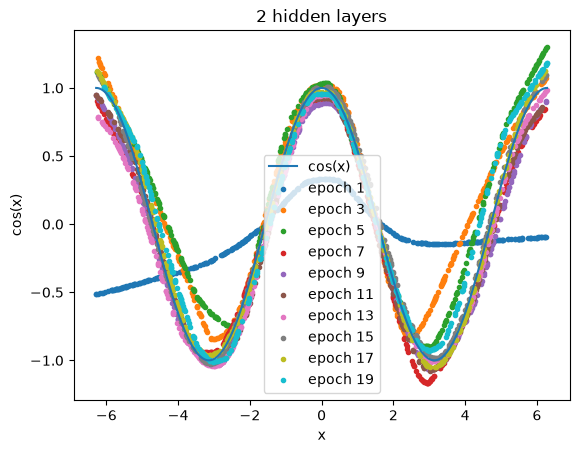

In [47]:
plt.plot(x, y, label='cos(x)')
plt.xlabel('x')
plt.ylabel('cos(x)')

for epoch in range(training_epochs):
    print(f"Epoch [{epoch + 1}/{training_epochs}]")
    for batch_index, (data, targets) in enumerate(tqdm(train_loader)):
        # Move data and targets to the device (GPU/CPU)
        data = data.to(device)
        targets = targets.to(device)

        # Forward pass: compute the model output
        scores = model(data)
        loss_ = loss(scores, targets)

        # Backward pass: compute the gradients
        optimizer.zero_grad()
        loss_.backward()

        # Optimization step: update the model parameters
        optimizer.step()

    if epoch % 2 == 0:
        plt.scatter(data.detach().numpy(), scores.detach().numpy(), marker='.', label=f"epoch {epoch + 1}")
    
    plt.legend()
    plt.title("2 hidden layers")



In [48]:
def check_accuracy(loader, model):
    """
    Checks the accuracy of the model on the given dataset loader.

    Parameters:
        loader: DataLoader
            The DataLoader for the dataset to check accuracy on.
        model: nn.Module
            The neural network model.
    """
    if loader.dataset.split == "train":
        print("Checking accuracy on training data")
    else:
        print("Checking accuracy on test data")

    num_correct = 0
    num_samples = 0
    model.eval()  # Set the model to evaluation mode

    with torch.no_grad():  # Disable gradient calculation
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            # Forward pass: compute the model output
            scores = model(x)
            num_correct += (scores.detach().numpy() - y.detach().numpy() < 0.00001).sum()  # Count correct predictions
            num_samples += len(scores.data) # Count total samples

        # Calculate accuracy
        accuracy = float(num_correct) / float(num_samples) * 100
        print(f"Got {num_correct}/{num_samples} with accuracy {accuracy:.2f}%")
    
    model.train()  # Set the model back to training mode

In [49]:
check_accuracy(train_loader, model)
check_accuracy(test_loader, model)

Checking accuracy on training data
Got 1590/4000 with accuracy 39.75%
Checking accuracy on test data
Got 394/1000 with accuracy 39.40%
